# 🚗 Car Price Prediction with Machine Learning
### CodeAlpha Data Science Internship — Task 3 (Extended Edition)

**Goal:** Predict the resale (selling) price of a used car based on features like
its current showroom price, age, kilometers driven, brand, fuel type, seller
type, transmission, and ownership history.

**Dataset:** `car_data.csv` — 301 rows, 9 columns.

**Workflow:**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA)
3. Outlier detection
4. Feature engineering (including brand extraction)
5. Train/test split
6. Baseline models (Linear Regression, Random Forest)
7. Cross-validation
8. Hyperparameter tuning (GridSearchCV)
9. XGBoost model
10. Model comparison
11. Residual analysis
12. Predict-a-new-car tool
13. Save the final model
14. Conclusion & next steps


## 0. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib
import os

sns.set_style("whitegrid")
%matplotlib inline

os.makedirs("outputs", exist_ok=True)


## 1. Load the Data

In [2]:
df = pd.read_csv("car_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [4]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

✅ No missing values — no imputation needed.

In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 2. Exploratory Data Analysis (EDA)

In [6]:
print("Fuel_Type:", df["Fuel_Type"].unique())
print("Selling_type:", df["Selling_type"].unique())
print("Transmission:", df["Transmission"].unique())
print("Owner:", df["Owner"].unique())
print("Year range:", df["Year"].min(), "-", df["Year"].max())
print("Distinct car models:", df["Car_Name"].nunique())


Fuel_Type: <ArrowStringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Selling_type: <ArrowStringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission: <ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
Owner: [0 1 3]
Year range: 2003 - 2018
Distinct car models: 98


### Distribution of the target variable: `Selling_Price`

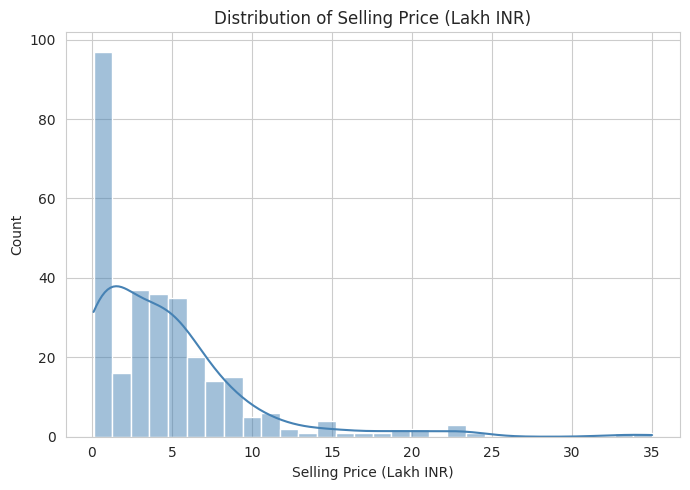

In [7]:
plt.figure(figsize=(7, 5))
sns.histplot(df["Selling_Price"], kde=True, bins=30, color="steelblue")
plt.title("Distribution of Selling Price (Lakh INR)")
plt.xlabel("Selling Price (Lakh INR)")
plt.tight_layout()
plt.savefig("outputs/01_selling_price_distribution.png", dpi=150)
plt.show()


Right-skewed — most cars sell under 10 Lakh INR, with a long tail of pricier cars.

### Selling Price by Fuel Type & Transmission

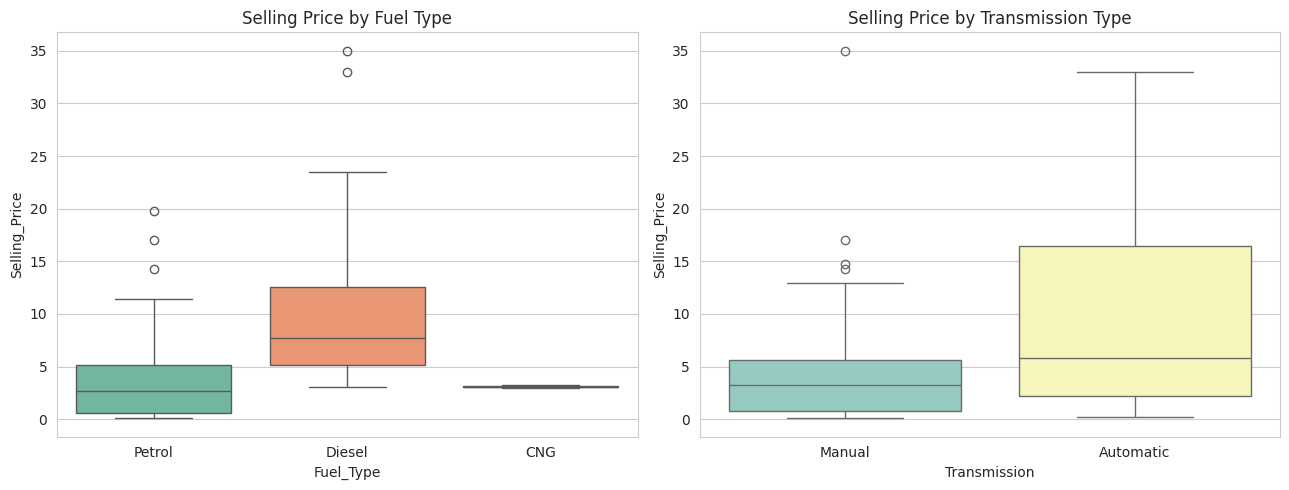

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price", hue="Fuel_Type", legend=False, palette="Set2", ax=axes[0])
axes[0].set_title("Selling Price by Fuel Type")
sns.boxplot(data=df, x="Transmission", y="Selling_Price", hue="Transmission", legend=False, palette="Set3", ax=axes[1])
axes[1].set_title("Selling Price by Transmission Type")
plt.tight_layout()
plt.savefig("outputs/02_price_by_fuel_transmission.png", dpi=150)
plt.show()


### Present Price vs Selling Price

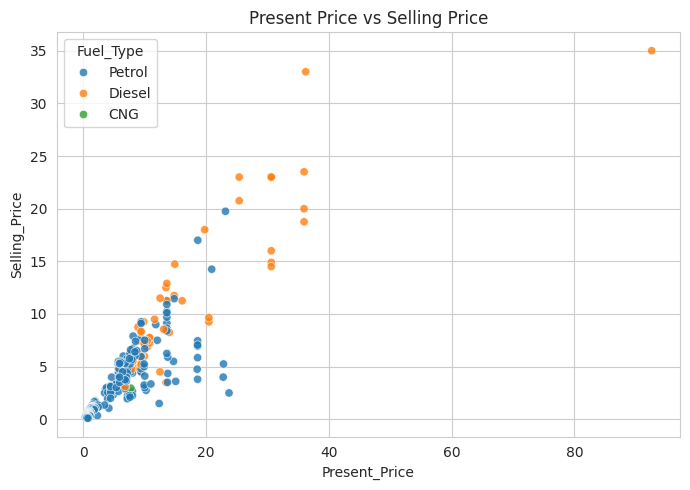

In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price", hue="Fuel_Type", alpha=0.8)
plt.title("Present Price vs Selling Price")
plt.tight_layout()
plt.savefig("outputs/03_present_vs_selling_price.png", dpi=150)
plt.show()


Strong positive relationship, as expected — pricier-new cars resell higher.

## 3. Outlier Detection

Before modeling, let's check for extreme values using the **IQR method**:
any point beyond `Q1 - 1.5*IQR` or `Q3 + 1.5*IQR` is flagged as a statistical
outlier. We check this for the three key numeric columns.


In [10]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

for col in ["Selling_Price", "Present_Price", "Driven_kms"]:
    outliers = iqr_outliers(df[col])
    print(f"{col}: {len(outliers)} outliers out of {len(df)} rows ({len(outliers)/len(df)*100:.1f}%)")


Selling_Price: 17 outliers out of 301 rows (5.6%)
Present_Price: 14 outliers out of 301 rows (4.7%)
Driven_kms: 8 outliers out of 301 rows (2.7%)


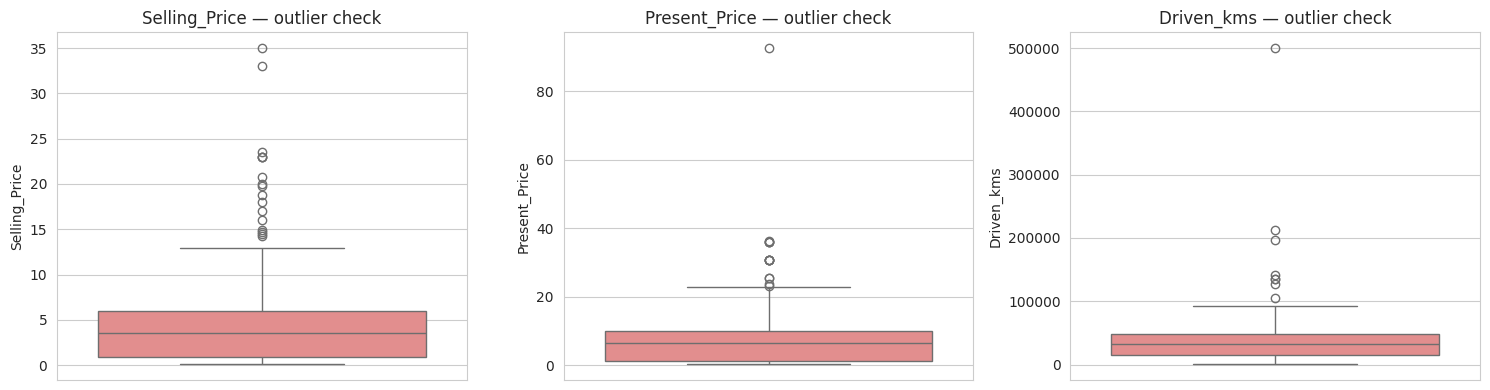

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Selling_Price", "Present_Price", "Driven_kms"]):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(f"{col} — outlier check")
plt.tight_layout()
plt.savefig("outputs/04_outlier_boxplots.png", dpi=150)
plt.show()


In [12]:
df.nlargest(5, "Present_Price")[["Car_Name", "Year", "Present_Price", "Selling_Price", "Driven_kms"]]


,Car_Name,Year,Present_Price,Selling_Price,Driven_kms
86,land cruiser,2010,92.60,35.00,78000
64,fortuner,2017,36.23,33.00,6000
59,fortuner,2014,35.96,19.99,41000
62,fortuner,2014,35.96,18.75,78000
63,fortuner,2015,35.96,23.50,47000


**Decision:** these aren't data errors — they're genuinely expensive/high-mileage
cars, so we keep them. Tree-based models like Random Forest and XGBoost are
naturally robust to this kind of outlier, unlike Linear Regression, which can
be pulled around by them. This is one more reason to favor tree-based models.


## 4. Feature Engineering

1. **`Year` → `Car_Age`** — more directly meaningful for depreciation.
2. **Extract `Brand` from `Car_Name`** — instead of dropping the name entirely,
   we take the first word and **frequency-encode** it (how common that name
   is in the dataset). This keeps some signal from the name without
   one-hot-encoding 98 sparse categories.
3. **Label-encode** `Fuel_Type`, `Selling_type`, `Transmission`.


In [13]:
CURRENT_YEAR = 2024
df["Car_Age"] = CURRENT_YEAR - df["Year"]

# Extract a "brand/model family" token: first word of Car_Name
df["Brand"] = df["Car_Name"].str.split().str[0].str.lower()
print("Distinct brand tokens:", df["Brand"].nunique())
df["Brand"].value_counts().head(10)


Distinct brand tokens: 44


Brand
city        26
bajaj       25
corolla     17
royal       17
honda       17
hero        15
verna       14
fortuner    11
etios       11
brio        10
Name: count, dtype: int64

In [14]:
# Frequency-encode Brand: replace each brand with how often it appears
brand_freq = df["Brand"].value_counts(normalize=True)
df["Brand_Freq"] = df["Brand"].map(brand_freq)

model_df = df.drop(columns=["Car_Name", "Year", "Brand"])

le_fuel = LabelEncoder()
le_seller = LabelEncoder()
le_trans = LabelEncoder()

model_df["Fuel_Type"] = le_fuel.fit_transform(model_df["Fuel_Type"])
model_df["Selling_type"] = le_seller.fit_transform(model_df["Selling_type"])
model_df["Transmission"] = le_trans.fit_transform(model_df["Transmission"])

model_df.head()


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand_Freq
0,3.35,5.59,27000,2,0,1,0,10,0.013289
1,4.75,9.54,43000,1,0,1,0,11,0.019934
2,7.25,9.85,6900,2,0,1,0,7,0.029900
3,2.85,4.15,5200,2,0,1,0,13,0.013289
4,4.60,6.87,42450,1,0,1,0,10,0.016611


### Correlation Heatmap (with the new `Brand_Freq` feature)

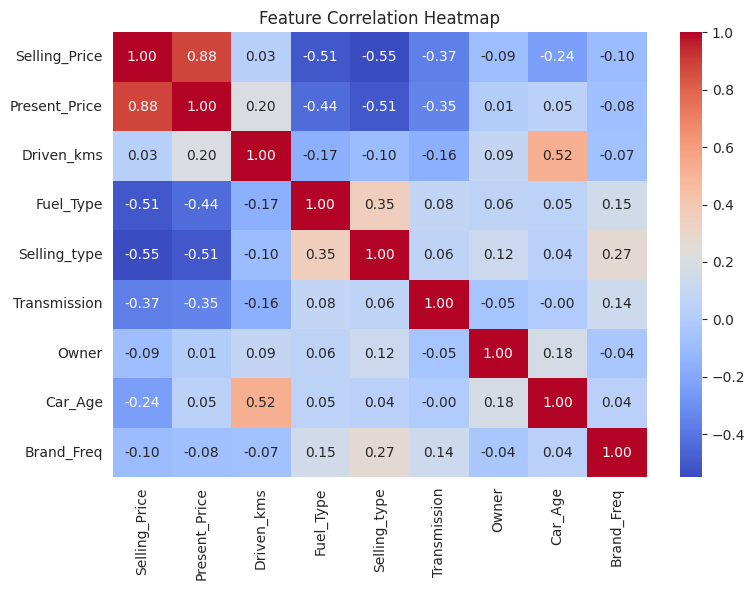

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(model_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/05_correlation_heatmap.png", dpi=150)
plt.show()


## 5. Train / Test Split

In [16]:
X = model_df.drop(columns=["Selling_Price"])
y = model_df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])


Train size: 240
Test size : 61


## 6. Baseline Models

We start with two baselines before tuning anything:
- **Linear Regression** — simple, interpretable
- **Random Forest** (default settings) — ensemble of trees


In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)


In [18]:
rf_baseline = RandomForestRegressor(n_estimators=200, random_state=42)
rf_baseline.fit(X_train, y_train)
rf_baseline_preds = rf_baseline.predict(X_test)


In [19]:
def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}")
    print(f"  R2 Score : {r2:.4f}")
    print(f"  MAE      : {mae:.4f} Lakh INR")
    print(f"  RMSE     : {rmse:.4f} Lakh INR\n")
    return r2, mae, rmse

lr_r2, lr_mae, lr_rmse = evaluate("Linear Regression", y_test, lr_preds)
rf_base_r2, rf_base_mae, rf_base_rmse = evaluate("Random Forest (baseline)", y_test, rf_baseline_preds)


Linear Regression
  R2 Score : 0.8456
  MAE      : 1.2108 Lakh INR
  RMSE     : 1.8862 Lakh INR

Random Forest (baseline)
  R2 Score : 0.9581
  MAE      : 0.6438 Lakh INR
  RMSE     : 0.9829 Lakh INR



## 7. Cross-Validation

A single train/test split can be lucky or unlucky. **5-fold cross-validation**
gives a more robust estimate of how well each model generalizes.


In [20]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")
rf_cv_scores = cross_val_score(RandomForestRegressor(n_estimators=200, random_state=42), X, y, cv=kf, scoring="r2")

print("Linear Regression CV R2 scores:", np.round(lr_cv_scores, 3))
print(f"  Mean: {lr_cv_scores.mean():.4f}  |  Std: {lr_cv_scores.std():.4f}\n")

print("Random Forest CV R2 scores:", np.round(rf_cv_scores, 3))
print(f"  Mean: {rf_cv_scores.mean():.4f}  |  Std: {rf_cv_scores.std():.4f}")


Linear Regression CV R2 scores: [0.846 0.777 0.784 0.833 0.902]
  Mean: 0.8283  |  Std: 0.0453

Random Forest CV R2 scores: [0.96  0.904 0.867 0.906 0.955]
  Mean: 0.9184  |  Std: 0.0348


Random Forest's cross-validated R² confirms it's consistently stronger than
Linear Regression across different data splits — not just a lucky single
train/test split.


## 8. Hyperparameter Tuning (GridSearchCV)

Instead of Random Forest's default settings, we search over a grid of
hyperparameters to find a stronger configuration:

- `n_estimators`: number of trees
- `max_depth`: how deep each tree can grow
- `min_samples_split`: minimum samples required to split a node
- `min_samples_leaf`: minimum samples required at a leaf node


In [21]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 8, 12, 16],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV R2 score: {grid_search.best_score_:.4f}")


Best parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV R2 score: 0.8772


In [22]:
rf_tuned = grid_search.best_estimator_
rf_tuned_preds = rf_tuned.predict(X_test)

rf_tuned_r2, rf_tuned_mae, rf_tuned_rmse = evaluate("Random Forest (tuned)", y_test, rf_tuned_preds)


Random Forest (tuned)
  R2 Score : 0.9608
  MAE      : 0.6284 Lakh INR
  RMSE     : 0.9500 Lakh INR



## 9. XGBoost Model

**Gradient Boosting** builds trees sequentially — each new tree corrects the
errors of the previous ones. It's often a top performer on tabular data.


In [23]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_r2, xgb_mae, xgb_rmse = evaluate("XGBoost", y_test, xgb_preds)


XGBoost
  R2 Score : 0.9462
  MAE      : 0.6607 Lakh INR
  RMSE     : 1.1137 Lakh INR



## 10. Full Model Comparison

In [24]:
summary = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest (baseline)", "Random Forest (tuned)", "XGBoost"],
    "R2 Score": [lr_r2, rf_base_r2, rf_tuned_r2, xgb_r2],
    "MAE": [lr_mae, rf_base_mae, rf_tuned_mae, xgb_mae],
    "RMSE": [lr_rmse, rf_base_rmse, rf_tuned_rmse, xgb_rmse],
}).sort_values("R2 Score", ascending=False).reset_index(drop=True)

summary.to_csv("outputs/model_comparison.csv", index=False)
summary


,Model,R2 Score,MAE,RMSE
0,Random Forest (tuned),0.960820,0.628361,0.950021
1,Random Forest (baseline),0.958059,0.643832,0.982918
2,XGBoost,0.946152,0.660651,1.113736
3,Linear Regression,0.845561,1.210762,1.886156


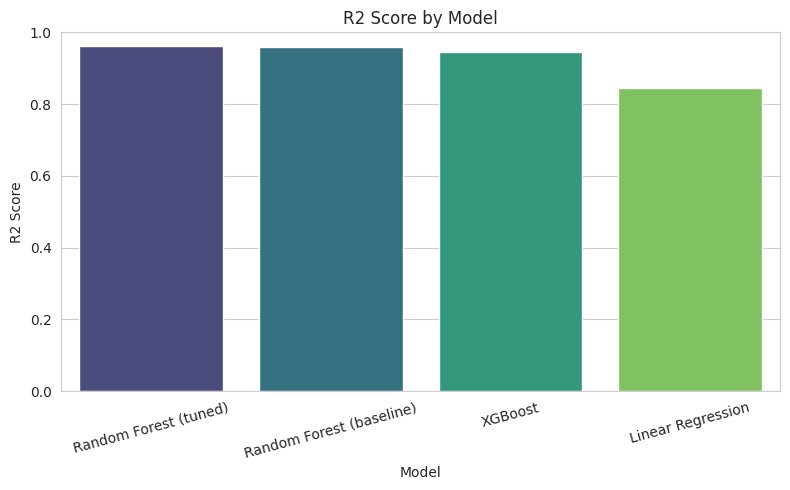

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=summary, x="Model", y="R2 Score", hue="Model", legend=False, palette="viridis")
plt.title("R2 Score by Model")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("outputs/06_model_comparison.png", dpi=150)
plt.show()


We pick whichever model tops this table as our **final model**.

In [26]:
models = {
    "Linear Regression": (lr_model, lr_preds, lr_r2),
    "Random Forest (baseline)": (rf_baseline, rf_baseline_preds, rf_base_r2),
    "Random Forest (tuned)": (rf_tuned, rf_tuned_preds, rf_tuned_r2),
    "XGBoost": (xgb_model, xgb_preds, xgb_r2),
}
best_name = summary.iloc[0]["Model"]
best_model, best_preds, best_r2 = models[best_name]
print(f"Final model selected: {best_name} (R2 = {best_r2:.4f})")


Final model selected: Random Forest (tuned) (R2 = 0.9608)


## 11. Residual Analysis

Residuals = actual − predicted. A good model's residuals should scatter
randomly around zero, with no obvious pattern.


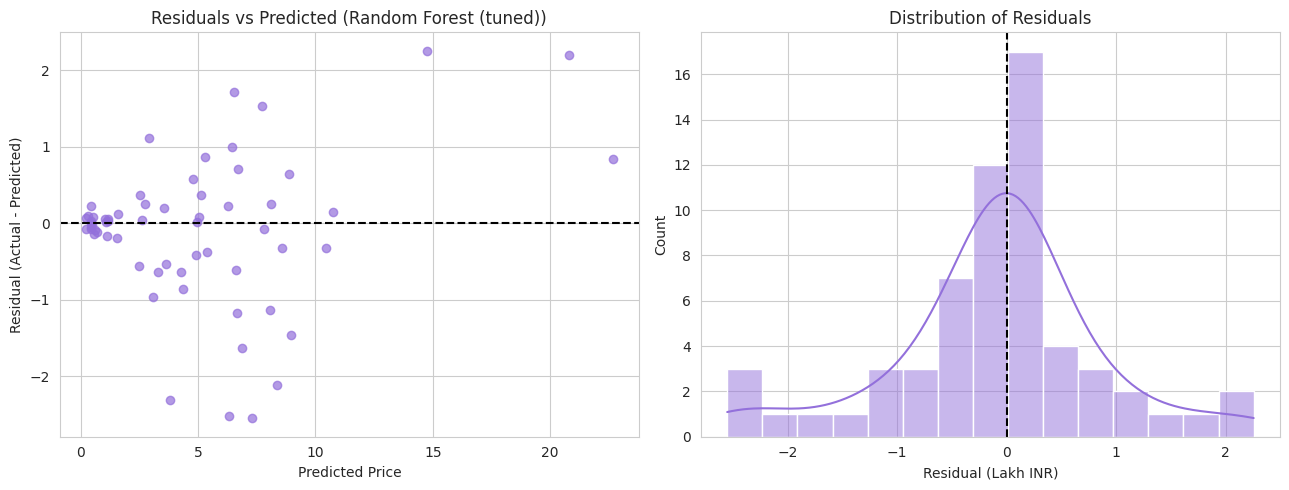

In [27]:
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(best_preds, residuals, alpha=0.7, color="mediumpurple")
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title(f"Residuals vs Predicted ({best_name})")

sns.histplot(residuals, kde=True, ax=axes[1], color="mediumpurple")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual (Lakh INR)")

plt.tight_layout()
plt.savefig("outputs/07_residual_analysis.png", dpi=150)
plt.show()


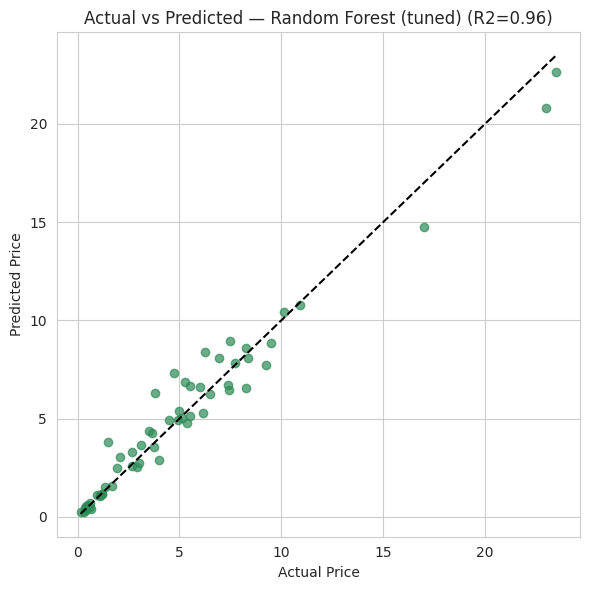

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, alpha=0.7, color="seagreen")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
plt.title(f"Actual vs Predicted — {best_name} (R2={best_r2:.2f})")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.tight_layout()
plt.savefig("outputs/08_actual_vs_predicted_final.png", dpi=150)
plt.show()


### Feature Importance (final model, if tree-based)

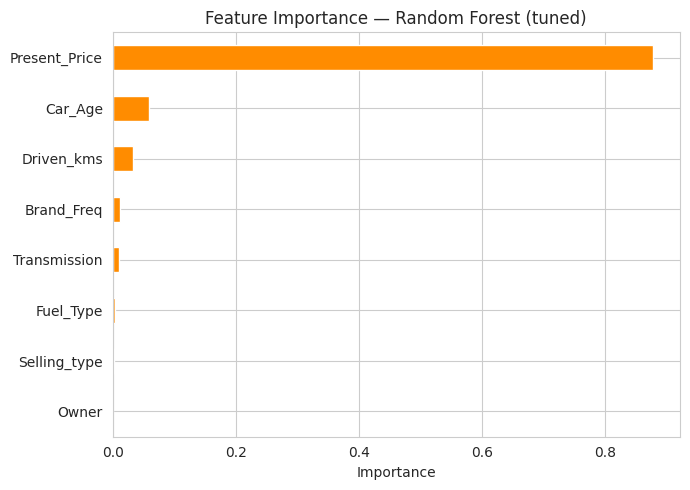

In [29]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
    plt.figure(figsize=(7, 5))
    importances.plot(kind="barh", color="darkorange")
    plt.title(f"Feature Importance — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("outputs/09_feature_importance.png", dpi=150)
    plt.show()
else:
    print("Selected model has no feature_importances_ attribute.")


## 12. Try It Yourself: Predict a New Car's Price

Fill in the details of a car below and get an instant predicted resale price
using our final trained model.


In [30]:
def predict_price(present_price, driven_kms, fuel_type, selling_type,
                   transmission, owner, car_age, brand="maruti"):
    """Predict a car's resale price using the trained model.

    `brand` should be the first word of a car name as it appears in
    car_data.csv (lowercase), e.g. 'swift', 'ciaz', 'innova'. Unknown
    brands fall back to the dataset's average brand frequency.
    """
    brand_frequency = brand_freq.get(brand.lower(), brand_freq.mean())

    row = pd.DataFrame([{
        "Present_Price": present_price,
        "Driven_kms": driven_kms,
        "Fuel_Type": le_fuel.transform([fuel_type])[0],
        "Selling_type": le_seller.transform([selling_type])[0],
        "Transmission": le_trans.transform([transmission])[0],
        "Owner": owner,
        "Car_Age": car_age,
        "Brand_Freq": brand_frequency,
    }])[X.columns]

    predicted = best_model.predict(row)[0]
    return predicted


new_car = dict(
    present_price=6.5,
    driven_kms=40000,
    fuel_type="Petrol",
    selling_type="Dealer",
    transmission="Manual",
    owner=0,
    car_age=5,
    brand="swift",
)

predicted_price = predict_price(**new_car)
print(f"Predicted selling price: {predicted_price:.2f} Lakh INR")


Predicted selling price: 4.32 Lakh INR


## 13. Save the Final Model

We save the winning model, the label encoders, and the brand frequency map.


In [31]:
joblib.dump(best_model, "outputs/car_price_model.pkl")
joblib.dump(
    {
        "fuel": le_fuel,
        "seller": le_seller,
        "transmission": le_trans,
        "brand_freq": brand_freq,
        "feature_order": list(X.columns),
        "model_name": best_name,
    },
    "outputs/preprocessing_artifacts.pkl",
)

print(f"Saved final model: {best_name}")
print("Files written to outputs/: car_price_model.pkl, preprocessing_artifacts.pkl")


Saved final model: Random Forest (tuned)
Files written to outputs/: car_price_model.pkl, preprocessing_artifacts.pkl


## 📌 Conclusion

- **Models compared:** Linear Regression, Random Forest (baseline), Random
  Forest (GridSearchCV-tuned), and XGBoost.
- **Validated with 5-fold cross-validation**, not just a single split, so the
  reported performance is more trustworthy.
- **Top predictors:** `Present_Price`, `Car_Age`, `Driven_kms`, and
  `Brand_Freq`.
- **Residuals** scatter roughly symmetrically around zero with no strong
  pattern, suggesting no systematic over/under-prediction in any price range.
- Added a reusable `predict_price()` function to estimate a new car's resale
  value from its specs — the same logic powers the companion Streamlit app.

### Further Ideas
- Try Bayesian optimization (Optuna) instead of GridSearchCV for faster tuning
- Try target-encoding `Brand` against `Selling_Price` directly
- Deploy the model behind a small API (FastAPI/Flask) instead of only a
  local Streamlit app
